# MULCL Threshold Spatial Hour-Count Maps and Skew-T Comparison

Purpose: Compare spatial patterns and atmospheric profiles for lightning-only land points
split by lifting condensation level (LCL) height threshold (< 1500m vs >= 1500m), under
convective conditions (MUCAPE > 0), for warm-season tropical Australia.

This notebook has two parts:

Part 1 — Spatial Hour-Count Maps:
Grids raw point-level data (0.11 degree resolution) for each MULCL threshold group,
counting hours per season with MUCAPE > 0 at each grid cell, and plots side-by-side
spatial maps to show where each LCL regime occurs most frequently across the region.

Part 2 — Skew-T/Log-P Comparison:
Plots a 2-panel Skew-T diagram (LCL < 1500m vs LCL >= 1500m) using the weighted-mean
vertical profiles and initial parcel parameters computed in
13_mulcl_threshold_weighted_profiles_for_skewT.ipynb, including virtual temperature
corrections and CAPE/CIN shading, with an LCL-level point inserted into each profile
for a smoother diagram near the LCL.

Input:
- Part 1: Raw categorized point CSVs (MULCL-threshold subsets):
  dialation_mucape/1_MULCL_{less,greater_equal}_1500m_mucape_0_ls_only_land_3d.csv
- Part 2: Weighted-mean vertical profile and initial parameter CSVs (from
  13_mulcl_threshold_weighted_profiles_for_skewT.ipynb):
  warm_Season_MULCL_condition/mean_param/mean_data_1_<group>.csv,
  warm_Season_MULCL_condition/mean_param/mean_initial_param_MULCL_mucape_0_ls_only_land_3d.csv
- Requires local atmos.thermo, atmos.moisture, atmos.utils modules

Processing:
- Part 1: Filter each CSV to warm-season months and MUCAPE > 0, snap points to a 0.11
  degree grid, count unique hours per grid cell (normalized per season), and plot as
  filled contour maps with coastlines and borders.
- Part 2: Compute environmental/parcel virtual temperature, LCL, and parcel profile;
  insert an LCL-level point into each curve for smoother CAPE/CIN shading; plot both
  threshold groups side-by-side with a shared legend.

Output:
- Spatial hour-count map figure:
  /g/data/if69/tp4064/Project_1/Plots/warm_season/1_MULCL_1500_warm_season.png
- Skew-T comparison figure:
  /g/data/if69/tp4064/Project_1/Plots/warm_season/
  1_insert_virtual_screen_parcel_MULCL_warm_skewTlogP.png

In [21]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt

def plot_panel(ax, lon2d, lat2d, data2d, title, level, vmin=None, vmax=None, font_size=8, cmap=None, panel_label=None):
    # ax.add_feature(cfeature.COASTLINE, )
    ax.coastlines(resolution='10m')
    ax.add_feature(cfeature.BORDERS,) # linewidth=0.)
    # ax.add_feature(cfeature.STATES, linewidth=0.3)
    
    
    levels = np.linspace(0,vmax,level)
    # cmap = plt.get_cmap('RdYlBu_r', levels-1)

    gl_dense = ax.gridlines(linestyle=':', draw_labels=False)
    gl_dense.xlocator = mticker.MultipleLocator(2.5)   # dense lines every 2°
    gl_dense.ylocator = mticker.MultipleLocator(1.5)

    if (ax == axes[0]):
    
        # ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
        gl = ax.gridlines(linestyle=':', draw_labels={"bottom": True, "left": True})
        gl.xlocator = mticker.MultipleLocator(5)
        
    else :

        gl = ax.gridlines(linestyle=':', draw_labels={"bottom": True, "left": False})
        gl.xlocator = mticker.MultipleLocator(5)

    gl.xlabel_style = {'size': font_size}
    gl.ylabel_style = {'size': font_size}
    # gl.tick_params(axis='both', which='major', labelsize=font_size, direction='out', length=4)
        

    if level is not None:
        
        cmap_obj = plt.get_cmap(cmap, len(levels) - 1)   # discrete colors, one per band
        norm = mcolors.BoundaryNorm(levels, cmap_obj.N)
        mesh = ax.pcolormesh(
            lon2d, lat2d, data2d,
            cmap=cmap_obj, norm=norm, shading="auto",
            transform=ccrs.PlateCarree()
        )
    else:
        mesh = ax.pcolormesh(
            lon2d, lat2d, data2d,
            cmap=cmap, shading="auto",
            transform=ccrs.PlateCarree()
        )

    
    # mesh = ax.pcolormesh(
    #     lon2d, lat2d, data2d,
    #     cmap=cmap, shading="auto", vmin=vmin, vmax=vmax,
    #     transform=ccrs.PlateCarree()
    # )
    ax.set_extent(
        [lon2d.min(), lon2d.max(), lat2d.min(), lat2d.max()],
        crs=ccrs.PlateCarree()
    )
    ax.set_title(title, fontsize = font_size+1)

    ax.text(0.01, 0.95, panel_label,transform=ax.transAxes,fontsize=font_size+2 ,fontweight = 'bold', va='top')
    return mesh


def process_data(filepath, grid_res=0.11, months_to_keep=(10, 11, 12, 1, 2, 3, 4),
                  value_col="MUCAPE", threshold=0, time_ref=None):
    """
    Load, filter, and grid a CSV of point data for pcolormesh plotting.

    Parameters
    ----------
    filepath : str
        Path to the CSV file.
    grid_res : float
        Grid resolution in degrees.
    months_to_keep : tuple
        Which months (1-12) to retain.
    value_col : str
        Column name to threshold/filter on (e.g. "MULCL").
    threshold : float
        Keep rows where value_col > threshold.
    time_ref : str or None
        If time is "hours since <ref>", pass reference date string (e.g. "1900-01-01").
        If None, assumes "time" column is already a parseable datetime string.

    Returns
    -------
    lon2d, lat2d, data2d : np.ndarray
        Meshgrid arrays ready for ax.pcolormesh(lon2d, lat2d, data2d, ...)
    """
    # --- 1. Load data ---
    df = pd.read_csv(filepath)
    df = df.rename(columns=str.strip)
    df.columns = [c.strip() for c in df.columns]

    # --- 2. Parse time & filter by month ---
    if time_ref is None:
        df["datetime"] = pd.to_datetime(df["time"])
    else:
        df["datetime"] = pd.to_datetime(time_ref) + pd.to_timedelta(df["time"], unit="h")

    df["month"] = df["datetime"].dt.month
    df = df[df["month"].isin(months_to_keep)].copy()

    # --- 3. Filter by value threshold ---
    df_pos = df[df[value_col] > threshold].copy()

    # --- 4. Snap to grid & count hours per cell ---
    df_pos["lat_grid"] = (np.round(df_pos["lat"] / grid_res) * grid_res).round(4)
    df_pos["lon_grid"] = (np.round(df_pos["lon"] / grid_res) * grid_res).round(4)

    counts = (
        df_pos.groupby(["lat_grid", "lon_grid"])["time"]
        .nunique()
        .reset_index(name="hour_count")
    )
    counts["hour_count"] = counts["hour_count"] / 8

    # --- 5. Build regular grid ---
    lat_vals = np.sort(counts["lat_grid"].unique())
    lon_vals = np.sort(counts["lon_grid"].unique())
    grid = pd.DataFrame(index=lat_vals, columns=lon_vals, dtype=float)

    for _, row in counts.iterrows():
        grid.loc[row["lat_grid"], row["lon_grid"]] = row["hour_count"]

    lon2d, lat2d = np.meshgrid(lon_vals, lat_vals)
    data2d = grid.values.astype(float)

    return lon2d, lat2d, data2d    

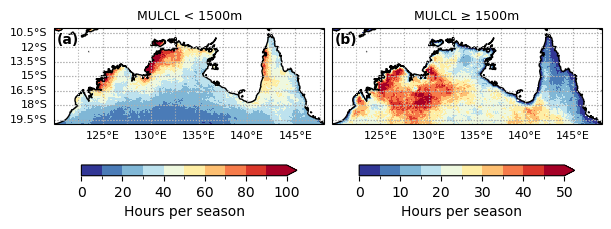

In [23]:
lon2d, lat2d, data2d = process_data(
    "/g/data/if69/tp4064/Project_1/categorical_position/dialation_mucape/1_MULCL_less_1500m_mucape_0_ls_only_land_3d.csv",
    grid_res=0.11, value_col="MUCAPE", threshold=0
)

lon2d_2, lat2d_2, data2d_2 = process_data(
    "/g/data/if69/tp4064/Project_1/categorical_position/dialation_mucape/1_MULCL_greater_equal_1500m_mucape_0_ls_only_land_3d.csv",
    grid_res=0.11, value_col="MUCAPE", threshold=0
)

# panel_labels = ['(a)', '(b)']

fig, axes = plt.subplots(1, 2, figsize=(6, 3.5),layout='compressed',
                          subplot_kw={"projection": ccrs.PlateCarree()})


mesh1 = plot_panel(axes[0], lon2d, lat2d, data2d, "MULCL < 1500m",level = 11, vmin = 0,
                   vmax = 100, cmap = 'RdYlBu_r', panel_label = '(a)')

mesh2 = plot_panel(axes[1], lon2d_2, lat2d_2, data2d_2, "MULCL ≥ 1500m",level=11, vmin = 0,
                   vmax = 50, cmap ='RdYlBu_r', panel_label = '(b)')


cbar1 = plt.colorbar(mesh1, ax=axes[0], shrink=0.8, extend='max', orientation='horizontal',pad=0.01)
# cbar1.set_ticks([20,40,60,80,100])

cbar1.set_label("Hours per season")

cbar2 = plt.colorbar(mesh2, ax=axes[1], shrink=0.8, extend='max',orientation='horizontal',pad=0.01)
cbar2.set_label("Hours per season")

# plt.tight_layout()
plt.savefig("/g/data/if69/tp4064/Project_1/Plots/warm_season/1_MULCL_1500_warm_season.png", dpi=300, bbox_inches="tight")
plt.show()

# this is where I am trying the inserting LCL pressur elevel in profiles.

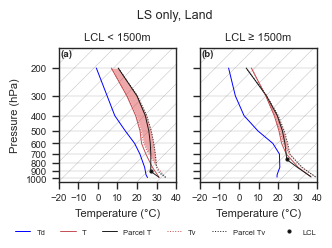

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from metpy.plots import SkewT
import metpy.calc as mpcalc
from metpy.units import units
import os
import seaborn as sns
from pathlib import Path

import numpy as np

import sys
import os
sys.path.append('/g/data/if69/tp4064/old_before_new_data_merge/BARRA_combine_data')
from atmos import thermo
from atmos import moisture
from atmos import utils


# 2. Define your 2 categories (rows)
# surface_types = ['land', 'ocean']
groups = ['1_MULCL_less_1500m_mucape_0_ls_only_land_3d','1_MULCL_greater_equal_1500m_mucape_0_ls_only_land_3d']
titles = ['LCL < 1500m', 'LCL ≥ 1500m']
panel_labels = ['(a)', '(b)']#, '(c)', '(d)', '(e)', '(f)']

data_dir = Path("/g/data/if69/tp4064/Project_1/categorical_position/BARRA_data_skew_T/warm_Season_MULCL_condition/mean_param")

sns.set_theme(style="ticks", context="paper") 
fig = plt.figure(figsize=(3, 1.5)) #(3, 1.5))
plot_idx = 1 # Counter for subplot position (1 to 6)
font_size = 7
line_width = 0.7



for col_group in groups:
    # Load your specific file for this group
    # Adjust path logic if land/ocean are in separate files or the same file
    # /mean_data_MULCL_MULCL_greater_equal_1500m_mucape_0_ls_only_land_3d.csv
   
    path = data_dir/f'mean_data_1_{col_group}.csv'
    mean_data = pd.read_csv(path)

    initial_path = data_dir/'mean_initial_param_MULCL_mucape_0_ls_only_land_3d.csv'
    initial_data = pd.read_csv(initial_path).set_index('year').loc[col_group]


    parcel_pres = initial_data.mean_MULPLpres/100
    parcel_temp = initial_data.mean_MULPLtemp-273.15
    parcel_dew = initial_data.mean_MULPLdew-273.15

    parcel_pressure_levels = mean_data.pressure.values.copy()
    
    # virtual temp calcualtion
    
    T = mean_data[f'1_{col_group}_temperature']+273.15
    
    q = moisture.specific_humidity_from_dewpoint_temperature(mean_data['pressure']*100,mean_data[f'1_{col_group}_dew']+273.15) # environmental specific humidity

 

    # note : for parcel pressur elevels, when parcel pressure is greater than 1000hpa, I could had inserted pressure 1000hpa
    # but it was creating alot problem while shading the CAPE, so it replaced it everywhere, wether greater than or less than.

    
    # Select data based on row (assuming 'land' and 'ocean' are columns in your CSV)
    # e.g., 'ot_only_land_temperature_nt'
    p_mean = (mean_data.pressure.values) * units.hPa
    t_col = f'1_{col_group}_temperature' 
    d_col = f'1_{col_group}_dew'
    
    t_mean = mean_data[t_col].values * units.degC
    dew_mean = mean_data[d_col].values * units.degC

    parcel_spec = moisture.specific_humidity_from_dewpoint_temperature(parcel_pres*100,parcel_dew+273.15)
    parcel_pressure_levels = parcel_pressure_levels* units.hPa
    parcel_pres = parcel_pres* units.hPa
    parcel_temp = parcel_temp* units.degC
    parcel_dew = parcel_dew* units.degC

    if ((parcel_pressure_levels[0] < parcel_pres) or (parcel_pressure_levels[0] > parcel_pres)): 
        parcel_pressure_levels[0] = parcel_pres


    # Calculate and plot Parcel / LCL
    lcl_p, lcl_t = mpcalc.lcl(parcel_pres, parcel_temp, parcel_dew)
    Tp = mpcalc.parcel_profile(parcel_pressure_levels, parcel_temp, parcel_dew)
    lcl_prof = Tp.to('degC')

    qp = np.where(parcel_pressure_levels.magnitude*100 < lcl_p.magnitude*100, 
                  thermo.saturation_specific_humidity(parcel_pressure_levels.magnitude*100, Tp.magnitude), parcel_spec)

    Tv = np.asarray(thermo.virtual_temperature(T, q)-273.15)*units.degC    # environmental virtual temperature
    Tvp = np.asarray(thermo.virtual_temperature(Tp.magnitude,qp)-273.15)*units.degC # parcel virtual temperature

    insert_idx = np.searchsorted(-p_mean, -lcl_p)
    p_mean_insert = np.insert(p_mean, insert_idx, lcl_p)
    t_mean_insert = np.insert(t_mean, insert_idx, lcl_t)
    dew_insert = utils.interp_scalar_to_pressure_level(p_mean.magnitude*100, dew_mean.magnitude, lcl_p.magnitude*100)
    dew_mean_insert = np.insert(dew_mean, insert_idx, dew_insert* units.degC)

    parcel_pressure_levels_insert = np.insert(parcel_pressure_levels, insert_idx, lcl_p)
    lcl_prof_insert = np.insert(lcl_prof, insert_idx, lcl_t)

    Tvp_insert = utils.interp_scalar_to_pressure_level(parcel_pressure_levels.magnitude*100, Tvp.magnitude, lcl_p.magnitude*100)
    Tvp_mean_insert = np.insert(Tvp, insert_idx, Tvp_insert*units.degC)
    
    

    # --- Initialize SkewT for this specific grid cell ---
    skewt = SkewT(fig=fig, subplot=(1, 2, plot_idx),rotation=45)
    skewt.ax.grid(True, which='both', color='grey', linestyle='-', linewidth=line_width-1, alpha=0.6)

    
    # Plot Temp and Dewpoint

    skewt.plot(p_mean_insert, dew_mean_insert, 'blue',linewidth = line_width,label='Td' )
    skewt.plot(p_mean, t_mean, 'r',linewidth = line_width, label='T' )
    skewt.plot(parcel_pressure_levels_insert, lcl_prof_insert, 'k', linestyle='-',linewidth = line_width,label='Parcel T')
    
    # # if plot_idx==1 else ""


    skewt.plot(p_mean, Tv, 'r',linestyle=':',linewidth = line_width, label='Tv' )
    skewt.plot(parcel_pressure_levels_insert, Tvp_mean_insert, 'k',linestyle=':',linewidth = line_width,label='Parcel Tv' )


    
    skewt.plot(lcl_p, lcl_t, 'ko', markerfacecolor='black', markersize = font_size-5, label='LCL')
    # skewt.plot(lcl_p, Tvp_insert*units.degC, 'ko', markerfacecolor='black', markersize = font_size-5, label='LCL')
    # skewt.shade_cape(p_mean, t_mean, lcl_prof)
    # skewt.shade_cin(p_mean, t_mean, lcl_prof)

    skewt.shade_cape(p_mean, Tv, Tvp)
    skewt.shade_cin(p_mean[:6], Tv[:6], Tvp_mean_insert[:6])

    

    # 3. Add Panel Label (e.g., (a), (b)...)
    # transform=skewt.ax.transAxes places it relative to the subplot box (0,0 is bottom left)
    skewt.ax.text(0.02, 0.99, panel_labels[plot_idx-1], 
                  transform=skewt.ax.transAxes, 
                  fontsize=font_size ,fontweight = 'bold', va='top')

    skewt.ax.tick_params(axis='x', labelsize=font_size)
    skewt.ax.tick_params(axis='y', labelsize=font_size)


    # Formatting individual subplot
            # --- Add Titles ONLY to the first row (indices 0, 1, 2) ---
    # if plot_idx <= 3:
    skewt.ax.set_title(titles[plot_idx-1], fontsize=font_size+1)
    skewt.ax.set_xlim(-20, 40)
    skewt.ax.set_ylim(1050, 150)


    # 2. Add Row Labels (Land/Ocean) to the first column
    if (plot_idx == 1) :
        # This adds a bold label to the left of the Y-axis
        skewt.ax.set_ylabel(f"Pressure (hPa)", 
                            fontsize=font_size+1 )
        handles, labels = skewt.ax.get_legend_handles_labels()
        
    elif plot_idx== 2:
        # Clear the label entirely for middle and right columns
        skewt.ax.set_ylabel("")
        # Remove Y-axis labels for middle/right columns to save space
        skewt.ax.set_yticklabels([])

    
    skewt.ax.set_xlabel('Temperature (°C)', fontsize=font_size+1 )
        

    plot_idx += 1

fig.legend(handles, labels, loc='lower center', ncol = 6,fontsize=font_size-1.5, bbox_to_anchor=(0.47,-0.3), frameon=False)
fig.suptitle('LS only, Land', fontsize=font_size + 2,  y=1.25) #fontweight='bold',
        

plt.subplots_adjust(
    left=0.1,    # Room for Land/Ocean text
    right=0.99,  # Edge of figure
    top=0.99,    # Room for 'OT Only' titles
    bottom=0.1, # Room for 'Temperature' label
    wspace=0.12, # NEGATIVE value pulls columns together
    hspace=0.08   # Space between Land and Ocean rows
)


plt.savefig("/g/data/if69/tp4064/Project_1/Plots/warm_season/1_insert_virtual_screen_parcel_MULCL_warm_skewTlogP.png", dpi = 400,bbox_inches='tight')
plt.show()
